links:
- https://www.geeksforgeeks.org/python/python-loop-through-folders-and-files-in-directory/

notes:
- to handle class imbalance (750/250) tell the loss function to care more about the minority class.
-

In [55]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rhythmghai/ai-vs-real-images-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\micha\.cache\kagglehub\datasets\rhythmghai\ai-vs-real-images-dataset\versions\1


## Import packages
---


In [38]:
import sys
print(sys.executable)

D:\Programs\anaconda3\envs\ai_fake_cnn\python.exe


In [56]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Activation, GlobalAveragePooling2D, Input
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping

### Load real images
---


In [57]:
path = kagglehub.dataset_download("rhythmghai/ai-vs-real-images-dataset")
dir = path + "/real_dataset/"

valid_extensions = (".jpg", ".jpeg", ".png")

# collect all sub-folder paths
sub_folder_paths = []

for root, dirs, files in os.walk(dir):
    for filename in files:
        if filename.lower().endswith(valid_extensions):
            sub_folder_paths.append(os.path.join(root, filename)) # append full path

images_real = [] # numpy Array (from cv2)
for path in sub_folder_paths:
    img = cv2.imread(path)

    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        images_real.append(img)

print(f'loaded {len(images_real)} images')


loaded 745 images


### Load Ai generated images
---


In [58]:
path = kagglehub.dataset_download("rhythmghai/ai-vs-real-images-dataset")
dir = path + "/Ai_generated_dataset/"
print(path)
print(dir)

valid_extensions = (".jpg", ".jpeg", ".png")

# collect all sub-folder paths
sub_folder_paths = []

for root, dirs, files in os.walk(dir):
    for filename in files:
        if filename.lower().endswith(valid_extensions):
            sub_folder_paths.append(os.path.join(root, filename)) # append full path

images_ai = []
for path in sub_folder_paths:
    img = cv2.imread(path)

    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        images_ai.append(img)

print(f'loaded {len(images_ai)} images')

C:\Users\micha\.cache\kagglehub\datasets\rhythmghai\ai-vs-real-images-dataset\versions\1
C:\Users\micha\.cache\kagglehub\datasets\rhythmghai\ai-vs-real-images-dataset\versions\1/Ai_generated_dataset/
loaded 250 images


# Standardize Image Sizes
----


In [42]:
IMG_SIZE = (224,224)

processed_real = [cv2.resize(img, IMG_SIZE) for img in images_real]
processed_ai = [cv2.resize(img, IMG_SIZE) for img in images_ai]

X_real = np.array(processed_real)
X_ai = np.array(processed_ai)

y_real = np.zeros(len(X_real), dtype=np.int32)  # class 0
y_ai = np.ones(len(X_ai), dtype=np.int32)       # class 1

X_combined = np.concatenate([X_real, X_ai], axis=0)
y_combined = np.concatenate([y_real, y_ai], axis=0)

# Train, Test Split
---


In [43]:
X_train, X_val, y_train, y_val = train_test_split(
    X_combined, y_combined,
    test_size=0.2,
    stratify=y_combined,
    random_state=42
)

# Data Augmentation
---


In [44]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomTranslation(height_factor=0.08, width_factor=0.08),
    tf.keras.layers.RandomContrast(0.15),
], name="data_augmentation")

# Build Tensorflow dataset
---


In [45]:
BUFFER_SIZE = len(X_combined)
SPLIT = 0.8
BATCH_SIZE = 32

train_ds = (tf.data.Dataset.from_tensor_slices((X_train, y_train))
            .shuffle(BUFFER_SIZE)
            .batch(BATCH_SIZE)
            .prefetch(buffer_size=tf.data.AUTOTUNE))

val_ds = (tf.data.Dataset.from_tensor_slices((X_val, y_val))
          .batch(BATCH_SIZE)
          .prefetch(buffer_size=tf.data.AUTOTUNE))

# Build Tensorflow CNN
---


In [46]:
model = Sequential([
    Input(shape=(224, 224, 3)),
    
    data_augmentation,
    
    # Rescale input
    Rescaling(1./255),
    
    # ————————————————————————————————————————————————————————————————
    # BLOCK 1: 128x128x3 -> 64x64x32
    # ————————————————————————————————————————————————————————————————
    Conv2D(32, (3, 3), padding='same', name='block1_conv1'),
    BatchNormalization(name='block1_bn1'),
    Activation('relu', name='block1_relu1'),

    Conv2D(32, (3, 3), padding='same', name='block1_conv2'),
    BatchNormalization(name='block1_bn2'),
    Activation('relu', name='block1_relu2'),

    MaxPooling2D((2, 2), name='block1_pool'),
    Dropout(0.5, name='block1_drop'), # Adjust dropout rate as needed

    # ————————————————————————————————————————————————————————————————
    # BLOCK 2: 64x64x32 -> 32x32x64
    # ————————————————————————————————————————————————————————————————
    Conv2D(64, (3, 3), padding='same', name='block2_conv1'),
    BatchNormalization(name='block2_bn1'),
    Activation('relu', name='block2_relu1'),

    Conv2D(64, (3, 3), padding='same', name='block2_conv2'),
    BatchNormalization(name='block2_bn2'),
    Activation('relu', name='block2_relu2'),

    MaxPooling2D((2, 2), name='block2_pool'),
    Dropout(0.5, name='block2_drop'),

    # ————————————————————————————————————————————————————————————————
    # BLOCK 3: 32x32x64 -> 16x16x128
    # ————————————————————————————————————————————————————————————————
    Conv2D(128, (3, 3), padding='same', name='block3_conv1'),
    BatchNormalization(name='block3_bn1'),
    Activation('relu', name='block3_relu1'),

    Conv2D(128, (3, 3), padding='same', name='block3_conv2'),
    BatchNormalization(name='block3_bn2'),
    Activation('relu', name='block3_relu2'),

    MaxPooling2D((2, 2), name='block3_pool'),
    Dropout(0.5, name='block3_drop'),

    # ————————————————————————————————————————————————————————————————
    # BLOCK 4: 16x16x128 -> 8x8x256
    # —————————————————————————————————────────────────———————————————
    Conv2D(256, (3, 3), padding='same', name='block4_conv1'),
    BatchNormalization(name='block4_bn1'),
    Activation('relu', name='block4_relu1'),

    Conv2D(256, (3, 3), padding='same', name='block4_conv2'),
    BatchNormalization(name='block4_bn2'),
    Activation('relu', name='block4_relu2'),

    MaxPooling2D((2, 2), name='block4_pool'),
    Dropout(0.5, name='block4_drop'),

    # ————————————————————————————————————————————————————————————————
    # BLOCK 5: 8x8x256 -> 4x4x512
    # ————————————————————————————————————————————————————————————————
    Conv2D(512, (3, 3), padding='same', name='block5_conv1'),
    BatchNormalization(name='block5_bn1'),
    Activation('relu', name='block5_relu1'),

    Conv2D(512, (3, 3), padding='same', name='block5_conv2'),
    BatchNormalization(name='block5_bn2'),
    Activation('relu', name='block5_relu2'),

    MaxPooling2D((2, 2), name='block5_pool'),
    Dropout(0.5, name='block5_drop'),

    # ————————————————————————————————————————————————————————————————
    # HEAD: Classification Layers
    # ————————————————————————————————————————————————————————————————
    GlobalAveragePooling2D(name='gap'),

    Dense(512, name='fc1'),
    BatchNormalization(name='fc1_bn'),
    Activation('relu', name='fc1_relu'),
    Dropout(0.5, name='fc1_drop'),

    Dense(256, name='fc2'),
    BatchNormalization(name='fc2_bn'),
    Activation('relu', name='fc2_relu'),
    Dropout(0.5, name='fc2_drop'),

    # Binary output (0 or 1)
    Dense(1, activation='sigmoid', name='output')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the Model
---


In [47]:
# Collect labels only from the training dataset
y_train = []

for _, labels in train_ds:
    y_train.extend(labels.numpy())

y_train = np.array(y_train)

# Compute class weights to handle class imbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_combined),
    y=y_combined
)

class_weight_dict = dict(enumerate(class_weights))

es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weight_dict,
    callbacks=[es],
    verbose=1
)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 106s 4s/step - accuracy: 0.6457 - loss: 0.7684 - val_accuracy: 0.7487 - val_loss: 0.6042
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 98s 4s/step - accuracy: 0.6947 - loss: 0.5632 - val_accuracy: 0.7487 - val_loss: 1.3919
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 110s 4s/step - accuracy: 0.7198 - loss: 0.4961 - val_accuracy: 0.7487 - val_loss: 0.6738
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 106s 4s/step - accuracy: 0.8003 - loss: 0.4839 - val_accuracy: 0.7487 - val_loss: 1.0031


# Test Data with val_ds
---

7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 604ms/step
True labels distribution:
Real: 149
AI: 50

Predicted probabilities:
min: 0.13119163
max: 0.14547735
mean: 0.13867664

Predicted labels distribution:
Real: 199
AI: 0
              precision    recall  f1-score   support

    Real (0)       0.75      1.00      0.86       149
      AI (1)       0.00      0.00      0.00        50

    accuracy                           0.75       199
   macro avg       0.37      0.50      0.43       199
weighted avg       0.56      0.75      0.64       199



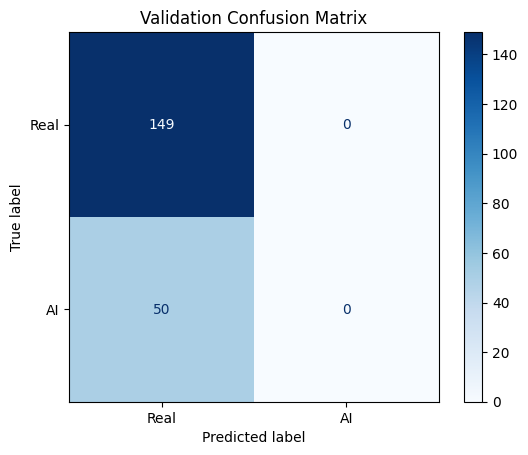

In [53]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_true = []
for _, labels in val_ds:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)

y_pred_probs = model.predict(val_ds)

# 3. Convert probabilities to binary choices (0 or 1)
y_pred = (y_pred_probs >= 0.5).astype(int).flatten()

print("True labels distribution:")
print("Real:", np.sum(y_true == 0))
print("AI:", np.sum(y_true == 1))

print("\nPredicted probabilities:")
print("min:", y_pred_probs.min())
print("max:", y_pred_probs.max())
print("mean:", y_pred_probs.mean())

print("\nPredicted labels distribution:")
print("Real:", np.sum(y_pred == 0))
print("AI:", np.sum(y_pred == 1))

# Print precision, recall, and F1-score
print(classification_report(
    y_true,
    y_pred,
    target_names=['Real (0)', 'AI (1)'],
    zero_division=0
))

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix visually
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Real', 'AI'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Validation Confusion Matrix")
plt.show()

# Save model to disk
---


In [49]:
# save model to disk
model.save("my_model.keras")

# Load model from disk
---


In [50]:
model = tf.keras.models.load_model("my_model.keras")

# Visualize some pictures of each class with its classification
---

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 503ms/step


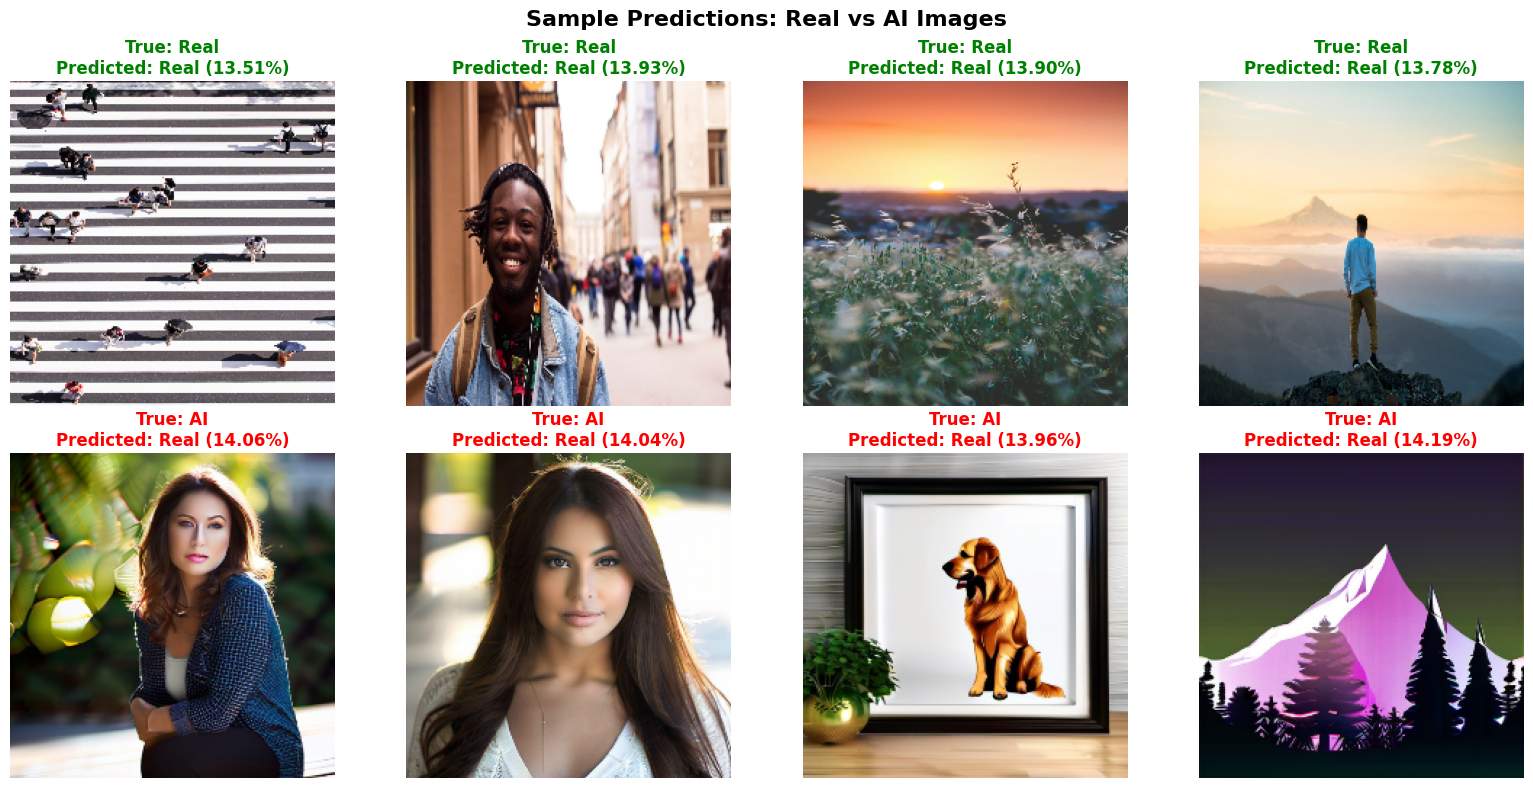

In [51]:
# Visualize sample predictions from each class
import matplotlib.pyplot as plt
import random

# Get samples from validation set
real_samples = []
ai_samples = []

for images, labels in val_ds:
    for img, label in zip(images.numpy(), labels.numpy()):
        if label == 0 and len(real_samples) < 4:
            real_samples.append(img)
        elif label == 1 and len(ai_samples) < 4:
            ai_samples.append(img)
        if len(real_samples) == 4 and len(ai_samples) == 4:
            break
    if len(real_samples) == 4 and len(ai_samples) == 4:
        break

# Combine samples
all_samples = real_samples + ai_samples
all_labels = [0]*len(real_samples) + [1]*len(ai_samples)

# Get predictions
predictions = model.predict(np.array(all_samples))
predicted_classes = (predictions >= 0.5).astype(int).flatten()

# Plot
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, (img, true_label, pred_class, pred_prob) in enumerate(zip(all_samples, all_labels, predicted_classes, predictions)):
    axes[idx].imshow(img.astype('uint8'))
    
    true_class_name = "Real" if true_label == 0 else "AI"
    pred_class_name = "Real" if pred_class == 0 else "AI"
    
    # Color: green if correct, red if wrong
    color = 'green' if true_label == pred_class else 'red'
    
    title = f"True: {true_class_name}\nPredicted: {pred_class_name} ({pred_prob[0]:.2%})"
    axes[idx].set_title(title, color=color, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle('Sample Predictions: Real vs AI Images', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()